# Задача 5. PageRank

**ФИО:** Непомнящий Матвей Тимофеевич  
**ИСУ:** 507189  
**Группа:** S4102


## Задача

Везде считаем, что вершины графа занумерованы подряд с **нуля**. Считаем на `python-graphblas`, `networkx` используем только для сверки.


## Импорты и загрузка графов

GraphBLAS для основных вычислений, `networkx` для сверки. Граф задаём матрицей смежности. Для бенчмарка возьмём `web-Stanford` (~280K вершин) из SNAP.


In [1]:
%matplotlib inline

import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 100

import graphblas as gb
gb.init("suitesparse", blocking=False)

from graphblas import Matrix, Vector, dtypes, unary, binary, monoid, semiring
from graphblas.io import mmread
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import os
import time
import tracemalloc
import urllib.request
import tarfile
import ssl
import gzip


`load_graph`, `to_binary`, `load_local_binary`: локальные `.mtx` из `lab_2/graphs_for_test/`.


In [2]:
GRAPH_ROOT = os.path.abspath(os.path.join("..", "lab_2", "graphs_for_test"))


def load_graph(path: str) -> Matrix:
    return mmread(path)


def to_binary(A: Matrix) -> Matrix:
    A = A.dup(dtype=dtypes.FP64)
    A << A.apply(unary.one)
    return A


def load_local_binary(rel_path: str) -> Matrix:
    path = os.path.join(GRAPH_ROOT, *rel_path.split("/"))
    return to_binary(load_graph(path))


`download_graph`, `load_suitesparse_binary`: SuiteSparse, кэш в `../data/suitesparse/`.


In [3]:
DOWNLOAD_DIR = "../data/suitesparse"
BASE_URL = "https://suitesparse-collection-website.herokuapp.com/MM"


def download_graph(group: str, name: str) -> str:
    graph_dir = os.path.join(DOWNLOAD_DIR, name)
    mtx_path = os.path.join(graph_dir, f"{name}.mtx")
    if os.path.exists(mtx_path):
        return mtx_path

    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    url = f"{BASE_URL}/{group}/{name}.tar.gz"
    tar_path = os.path.join(DOWNLOAD_DIR, f"{name}.tar.gz")
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE

    req = urllib.request.Request(url)
    with urllib.request.urlopen(req, context=ctx, timeout=120) as resp:
        with open(tar_path, "wb") as f:
            f.write(resp.read())

    with tarfile.open(tar_path, "r:gz") as tf:
        tf.extractall(DOWNLOAD_DIR)
    os.remove(tar_path)

    if not os.path.exists(mtx_path):
        for root, _, files in os.walk(graph_dir):
            for f in files:
                if f.endswith(".mtx"):
                    return os.path.join(root, f)
    return mtx_path


def load_suitesparse_binary(group: str, name: str) -> Matrix:
    return to_binary(load_graph(download_graph(group, name)))


`load_snap_web_stanford`: список рёбер SNAP, id вершин перенумеруем с 0.


In [4]:
def load_snap_web_stanford() -> Matrix:
    snap_dir = os.path.abspath(os.path.join("..", "data", "snap"))
    txt_path = os.path.join(snap_dir, "web-Stanford.txt")
    gz_path = txt_path + ".gz"
    if not os.path.exists(txt_path):
        os.makedirs(snap_dir, exist_ok=True)
        url = "https://snap.stanford.edu/data/web-Stanford.txt.gz"
        ctx = ssl.create_default_context()
        ctx.check_hostname = False
        ctx.verify_mode = ssl.CERT_NONE
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        print("  Downloading web-Stanford from SNAP ...")
        with urllib.request.urlopen(req, context=ctx, timeout=300) as resp:
            with open(gz_path, "wb") as f:
                f.write(resp.read())
        with gzip.open(gz_path, "rt", encoding="utf-8", errors="ignore") as fin:
            with open(txt_path, "w", encoding="utf-8") as fout:
                fout.write(fin.read())

    node_map = {}
    rows, cols = [], []
    with open(txt_path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            if not line or line[0] == "#":
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            u, v = int(parts[0]), int(parts[1])
            if u not in node_map:
                node_map[u] = len(node_map)
            if v not in node_map:
                node_map[v] = len(node_map)
            rows.append(node_map[u])
            cols.append(node_map[v])
    n = len(node_map)
    return Matrix.from_coo(rows, cols, [1.0] * len(rows), nrows=n, ncols=n, dtype=dtypes.FP64)


`gb_to_nx`, `l1_diff`, `max_abs_diff`: сравнение с `nx.pagerank`.


In [5]:
def gb_to_nx(A: Matrix) -> nx.DiGraph:
    rows, cols, _ = A.to_coo()
    G = nx.DiGraph()
    G.add_nodes_from(range(A.nrows))
    G.add_edges_from(zip(rows.tolist(), cols.tolist()))
    return G


def nx_pr_to_vector(pr_dict: dict, n: int) -> Vector:
    v = Vector(dtypes.FP64, n)
    for node, val in pr_dict.items():
        v[node] = val
    return v


def l1_diff(a: Vector, b: Vector) -> float:
    diff = a.ewise_mult(b, binary.minus).new()
    diff << diff.apply(unary.abs)
    return diff.reduce(monoid.plus).new().value


def max_abs_diff(a: Vector, b: Vector) -> float:
    diff = a.ewise_mult(b, binary.minus).new()
    diff << diff.apply(unary.abs)
    return diff.reduce(monoid.max).new().value


`generate_random_digraph`: случайный граф для тестов.


In [6]:
def generate_random_digraph(n: int, p: float, seed: int = 42) -> Matrix:
    G = nx.erdos_renyi_graph(n, p, seed=seed, directed=True)
    return gb.io.from_networkx(G, dtype=dtypes.FP64)


## Задание 1. Масштабирование на большом графе

Напишем обычный PageRank на GraphBLAS и будем сравнивать с ним остальные варианты. Если у вершины нет исходящих рёбер, её ранг равномерно распределяется по всем вершинам.


In [7]:
class PowerIterationFailedConvergence(Exception):
    pass


def _pagerank_core(
    A: Matrix,
    alpha: float = 0.85,
    max_iter: int = 100,
    tol: float = 1e-6,
    vec_dtype=dtypes.FP64,
    mxv_chunk: int | None = None,
):
    n = A.nrows
    assert A.nrows == A.ncols

    p = Vector(vec_dtype, n)
    p[:] << 1.0 / n

    d_out = A.reduce_rowwise(monoid.plus).new(dtype=vec_dtype)
    is_dangling = Vector(vec_dtype, n)
    is_dangling[:] << 1.0
    is_dangling(mask=d_out.S)[:] << 0.0
    has_dangling = is_dangling.reduce(monoid.plus).new().value > 0

    r = Vector(vec_dtype, n)
    r[:] << 1.0 / n
    M = A.dup(dtype=vec_dtype)

    def transposed_mxv(w: Vector) -> Vector:
        if mxv_chunk is None or n <= mxv_chunk:
            return M.T.mxv(w, semiring.plus_times).new()
        acc = Vector(vec_dtype, n)
        for r0 in range(0, n, mxv_chunk):
            r1 = min(r0 + mxv_chunk, n)
            block = M[r0:r1, :].new()
            w_part = w[r0:r1].new()
            part = block.T.mxv(w_part, semiring.plus_times).new()
            acc(binary.plus) << part
        return acc

    n_iters = 0
    err = float("inf")
    for n_iters in range(1, max_iter + 1):
        r_old = r.dup()
        w = r_old.ewise_mult(d_out, binary.truediv).new()

        if has_dangling:
            dangling_sum = r_old.ewise_mult(is_dangling, binary.times).new()
            dangling_sum = dangling_sum.reduce(monoid.plus).new().value
        else:
            dangling_sum = 0.0

        r << p.apply(binary.times, right=(1.0 - alpha))
        if has_dangling and dangling_sum > 0:
            r(binary.plus) << p.apply(binary.times, right=alpha * dangling_sum)
        link = transposed_mxv(w)
        if link.nvals > 0:
            r(binary.plus) << link.apply(binary.times, right=alpha)

        t = r.dup()
        t(binary.minus) << r_old
        t << t.apply(unary.abs)
        err = t.reduce(monoid.plus).new().value
        if err < n * tol:
            return r, n_iters, err

    raise PowerIterationFailedConvergence(
        f"PageRank failed to converge in {max_iter} iterations (err={err:.2e})"
    )


def pagerank(A: Matrix, alpha: float = 0.85, max_iter: int = 100, tol: float = 1e-6):
    r, _, _ = _pagerank_core(A, alpha=alpha, max_iter=max_iter, tol=tol)
    return r


Быстрая версия: числа в формате FP32 и поэтапное умножение матрицы на вектор блоками по 4096 строк.


In [8]:
def pagerank_fp32(A: Matrix, alpha: float = 0.85, max_iter: int = 100, tol: float = 1e-6, mxv_chunk: int | None = None):
    A32 = A.dup(dtype=dtypes.FP32)
    r32, n_iters, err = _pagerank_core(
        A32, alpha=alpha, max_iter=max_iter, tol=tol,
        vec_dtype=dtypes.FP32, mxv_chunk=mxv_chunk,
    )
    r = Vector(dtypes.FP64, A.nrows)
    for i in range(A.nrows):
        r[i] = float(r32[i].value)
    return r, n_iters, err


def benchmark_pagerank_variants(A: Matrix, n_runs: int = 3, **kwargs):
    if A.nrows > 100_000:
        n_runs = 1
    rows = []
    for name, dtype, chunk in [
        ("baseline_fp64", dtypes.FP64, None),
        ("optimized_fp32", dtypes.FP32, None),
        ("fp32_block_mxv", dtypes.FP32, 4096),
    ]:
        times, peaks, iters = [], [], []
        for _ in range(n_runs):
            tracemalloc.start()
            t0 = time.perf_counter()
            A_run = A.dup(dtype=dtype)
            _, it, _ = _pagerank_core(A_run, vec_dtype=dtype, mxv_chunk=chunk, **kwargs)
            times.append(time.perf_counter() - t0)
            peaks.append(tracemalloc.get_traced_memory()[1])
            iters.append(it)
            tracemalloc.stop()
        rows.append({
            "variant": name,
            "time_s": float(np.mean(times)),
            "peak_mem_mb": float(np.mean(peaks)) / (1024 * 1024),
            "iters": int(round(np.mean(iters))),
        })
    return pd.DataFrame(rows)


### Тесты

Сверим наш `pagerank` с `nx.pagerank`, результаты должны совпадать.


In [9]:
def assert_pagerank_matches_nx(A: Matrix, G: nx.DiGraph | None = None, tolerance: float = 1e-4, **kwargs):
    if G is None:
        G = gb_to_nx(A)
    our_pr = pagerank(A, **kwargs)
    nx_pr = nx.pagerank(G, **kwargs)
    diff = l1_diff(our_pr, nx_pr_to_vector(nx_pr, A.nrows))
    assert diff < tolerance, f"L1 diff = {diff:.2e}"
    return diff


A_small = Matrix.from_coo(
    [0, 0, 1, 2, 2, 3, 4], [1, 2, 3, 3, 4, 4, 0], [1.0] * 7,
    nrows=5, ncols=5, dtype=dtypes.FP64,
)
A_path = gb.io.from_networkx(nx.path_graph(5, create_using=nx.DiGraph), dtype=dtypes.FP64)
A_dangling = Matrix.from_coo([0, 0, 1], [1, 2, 2], [1, 1, 1], nrows=4, ncols=4, dtype=dtypes.FP64)


### Тест: `practice_5v`

Граф из практики, 5 вершин.


In [10]:
name = "practice_5v"
A = A_small
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
diff = assert_pagerank_matches_nx(A)
print(f"{name}: L1 diff = {diff:.2e} OK")


practice_5v: |V|=5, nnz(A)=7
practice_5v: L1 diff = 0.00e+00 OK


### Тест: `path_5`

Ориентированная цепочка из 5 вершин.


In [11]:
name = "path_5"
A = A_path
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
diff = assert_pagerank_matches_nx(A)
print(f"{name}: L1 diff = {diff:.2e} OK")


path_5: |V|=5, nnz(A)=4
path_5: L1 diff = 5.55e-17 OK


### Тест: `cycle_6`

Ориентированный 6-цикл.


In [12]:
name = "cycle_6"
A = gb.io.from_networkx(nx.cycle_graph(6, create_using=nx.DiGraph), dtype=dtypes.FP64)
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
diff = assert_pagerank_matches_nx(A)
print(f"{name}: L1 diff = {diff:.2e} OK")


cycle_6: |V|=6, nnz(A)=6
cycle_6: L1 diff = 0.00e+00 OK


### Тест: `star_5`

Звезда, рёбра к центру.


In [13]:
name = "star_5"
A = gb.io.from_networkx(nx.star_graph(4).to_directed(), dtype=dtypes.FP64)
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
diff = assert_pagerank_matches_nx(A)
print(f"{name}: L1 diff = {diff:.2e} OK")


star_5: |V|=5, nnz(A)=8
star_5: L1 diff = 0.00e+00 OK


### Тест: `complete_4`

Полный ориентированный граф на 4 вершинах.


In [14]:
name = "complete_4"
A = gb.io.from_networkx(nx.complete_graph(4).to_directed(), dtype=dtypes.FP64)
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
diff = assert_pagerank_matches_nx(A)
print(f"{name}: L1 diff = {diff:.2e} OK")


complete_4: |V|=4, nnz(A)=12
complete_4: L1 diff = 0.00e+00 OK


### Тест: `erdos_50`

Случайный граф, 50 вершин.


In [15]:
name = "erdos_50"
A = generate_random_digraph(50, 0.1, seed=42)
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
diff = assert_pagerank_matches_nx(A)
print(f"{name}: L1 diff = {diff:.2e} OK")


erdos_50: |V|=50, nnz(A)=232
erdos_50: L1 diff = 1.67e-16 OK


### Тест: `dangling`

Есть вершина без исходящих рёбер.


In [16]:
name = "dangling"
A = A_dangling
print(f"{name}: |V|={A.nrows}, nnz(A)={A.nvals}")
diff = assert_pagerank_matches_nx(A)
print(f"{name}: L1 diff = {diff:.2e} OK")


dangling: |V|=4, nnz(A)=3
dangling: L1 diff = 0.00e+00 OK


### Тест: разные коэффициенты затухания

Проверим alpha = 0.5, 0.85 и 0.99 на графе `practice_5v`.


In [17]:
for alpha in [0.5, 0.85, 0.99]:
    diff = assert_pagerank_matches_nx(A_small, alpha=alpha, max_iter=500)
    print(f"alpha={alpha}: L1 diff = {diff:.2e} OK")


alpha=0.5: L1 diff = 0.00e+00 OK
alpha=0.85: L1 diff = 0.00e+00 OK
alpha=0.99: L1 diff = 0.00e+00 OK


### Тест: граничные случаи

Граф из одной вершины; пустой граф 5 на 5; случайный граф на 200 вершин.


In [18]:
A_single = Matrix(dtypes.FP64, 1, 1)
pr = pagerank(A_single)
assert abs(pr[0].value - 1.0) < 1e-10
print("single_vertex: OK")

A_disconn = Matrix(dtypes.FP64, 5, 5)
pr = pagerank(A_disconn)
assert all(abs(pr[i].value - 0.2) < 1e-10 for i in range(5))
print("disconnected: OK")

G_rand = nx.erdos_renyi_graph(200, 0.05, seed=123, directed=True)
A_rand = gb.io.from_networkx(G_rand, dtype=dtypes.FP64)
diff = assert_pagerank_matches_nx(A_rand, G=G_rand)
print(f"random n=200: |V|={A_rand.nrows}, L1 diff = {diff:.2e} OK")


single_vertex: OK
disconnected: OK
random n=200: |V|=200, L1 diff = 5.55e-17 OK


### Бенчмарк

Загрузим `web-Stanford` из SNAP. Сравним обычную версию (FP64) с FP32 и FP32+block.


In [19]:
def load_large_graph():
    candidates = [
        ("snap", "web-Stanford", None),
        ("suitesparse", "Gleich", "wb-cs-stanford"),
        ("local", "email/email.mtx", None),
        ("local", "ca-GrQc/ca-GrQc.mtx", None),
    ]
    best = None
    for kind, a, b in candidates:
        try:
            if kind == "snap":
                A = load_snap_web_stanford()
                name = a
            elif kind == "suitesparse":
                A = load_suitesparse_binary(a, b)
                name = f"{a}/{b}"
            else:
                A = load_local_binary(a)
                name = a
            if best is None or A.nrows > best[0].nrows:
                best = (A, name)
            print(f"  loaded {name}: n={A.nrows}, edges={A.nvals}")
        except Exception as e:
            print(f"skip {a}: {e}")
    if best is not None:
        return best
    A = generate_random_digraph(100_000, 0.00005, seed=7)
    return A, "random_100k"


A_large, large_name = load_large_graph()
print(f"Граф: {large_name}, n={A_large.nrows}, edges={A_large.nvals}")


  loaded web-Stanford: n=281903, edges=2312497
  loaded Gleich/wb-cs-stanford: n=9914, edges=36854
  loaded email/email.mtx: n=1133, edges=10902
  loaded ca-GrQc/ca-GrQc.mtx: n=5242, edges=28980
Граф: web-Stanford, n=281903, edges=2312497


In [20]:
df_large = benchmark_pagerank_variants(A_large, n_runs=3, alpha=0.85, tol=1e-6, max_iter=100)
max_rank_diff = max_abs_diff(pagerank(A_large), pagerank_fp32(A_large)[0])
print(f"max rank diff (FP64 vs FP32) = {max_rank_diff:.3e}")
print(f"iters: {dict(zip(df_large.variant, df_large.iters))}")
df_large


max rank diff (FP64 vs FP32) = 6.763e-07
iters: {'baseline_fp64': 3, 'optimized_fp32': 3, 'fp32_block_mxv': 3}


,variant,time_s,peak_mem_mb,iters
0,baseline_fp64,0.086153,78.329078,3
1,optimized_fp32,0.087773,59.906131,3
2,fp32_block_mxv,0.591982,163.211387,3


### Визуализация

Время и пиковая память по вариантам из `df_large` (график в ноутбуке).


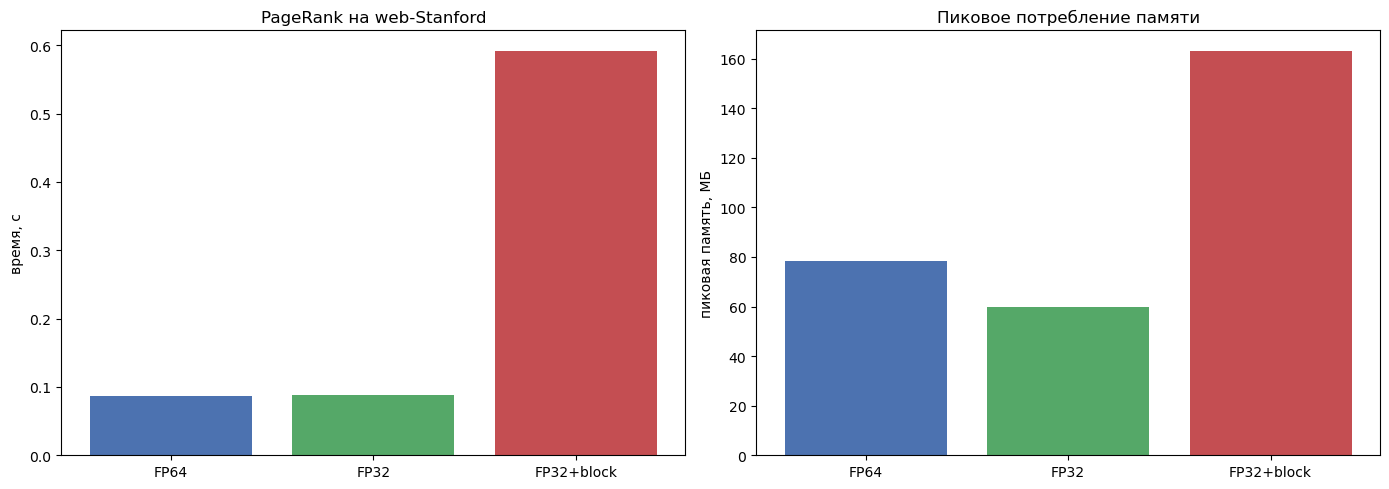

In [21]:
labels = {
    "baseline_fp64": "FP64",
    "optimized_fp32": "FP32",
    "fp32_block_mxv": "FP32+block",
}
plot_df = df_large.copy()
plot_df["label"] = plot_df["variant"].map(labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(plot_df["label"], plot_df["time_s"], color=["#4c72b0", "#55a868", "#c44e52"])
axes[0].set_ylabel("время, с")
axes[0].set_title(f"PageRank на {large_name}")
axes[1].bar(plot_df["label"], plot_df["peak_mem_mb"], color=["#4c72b0", "#55a868", "#c44e52"])
axes[1].set_ylabel("пиковая память, МБ")
axes[1].set_title("Пиковое потребление памяти")
plt.tight_layout()
plt.show()


### Выводы (задание 1)

По результатам на web-Stanford (таблица `df_large`, график выше):

1. Время: FP64 0.086 с, FP32 0.088 с, FP32+block 0.592 с. Блочный вариант медленнее из-за накладных расходов на разбиение матрицы.
2. Память: FP32 59.9 МБ, FP64 78.3 МБ, FP32+block 163.2 МБ. FP32 снижает пиковое потребление примерно на 24%.
3. Итерации: у всех вариантов 3 итерации до сходимости при alpha=0.85, формат чисел на это не влияет.
4. Точность: max-разность рангов FP64 и FP32 равна 6.76e-7, это пренебрежимо мало.

Итог: FP32 экономит память без потери точности; блочное умножение на этом графе выигрыша не даёт.


## Задание 2. Инкрементальный PageRank

После добавления новых рёбер пересчитываем ранги не с нуля, а только поправкой к старым значениям.


In [22]:
def incremental_pagerank(A_old: Matrix, r_old: Vector, new_edges: list, damping: float = 0.85, max_iter: int = 50, tol: float = 1e-6):
    alpha = damping
    n = A_old.nrows
    A_new = A_old.dup()
    for src, dst in new_edges:
        A_new[src, dst] = 1.0

    d_out_old = A_old.reduce_rowwise(monoid.plus).new(dtype=dtypes.FP64)
    d_out_new = A_new.reduce_rowwise(monoid.plus).new(dtype=dtypes.FP64)

    w_old = r_old.ewise_mult(d_out_old, binary.truediv).new()
    link_old = A_old.T.mxv(w_old, semiring.plus_times).new()
    link_new_r = A_new.T.mxv(r_old.ewise_mult(d_out_new, binary.truediv).new(), semiring.plus_times).new()
    delta_mt_r = link_new_r.ewise_mult(link_old, binary.minus).new()

    delta_r = Vector(dtypes.FP64, n)
    delta_r[:] << 0.0

    for _ in range(max_iter):
        delta_r_prev = delta_r.dup()
        w_delta = delta_r.ewise_mult(d_out_new, binary.truediv).new()
        link_delta = A_new.T.mxv(w_delta, semiring.plus_times).new()
        delta_r << link_delta.apply(binary.times, right=alpha)
        delta_r(binary.plus) << delta_mt_r.apply(binary.times, right=alpha)

        t = delta_r.dup()
        t(binary.minus) << delta_r_prev
        t << t.apply(unary.abs)
        if t.reduce(monoid.plus).new().value < n * tol:
            break

    r_new = r_old.ewise_mult(delta_r, binary.plus).new()
    s = r_new.reduce(monoid.plus).new().value
    r_new << r_new.apply(binary.truediv, right=s)
    return r_new


### Тест (+100 рёбер)

1. Считаем PageRank на исходном графе.
2. Добавляем 100 случайных рёбер.
3. Обновляем ранги через `incremental_pagerank`.
4. Считаем PageRank заново на обновлённом графе.
5. Сравниваем максимальную разницу рангов и время.

Граф: 800 вершин, вероятность ребра 0.01.


In [23]:
np.random.seed(42)
A_base = generate_random_digraph(800, 0.01, seed=11)
r_full = pagerank(A_base)

new_edges = [(int(np.random.randint(0, A_base.nrows)), int(np.random.randint(0, A_base.nrows))) for _ in range(100)]
A_updated = A_base.dup()
for s, d in new_edges:
    A_updated[s, d] = 1.0

tracemalloc.start()
t0 = time.perf_counter()
r_incr = incremental_pagerank(A_base, r_full, new_edges)
t_incr = time.perf_counter() - t0
mem_incr = tracemalloc.get_traced_memory()[1]
tracemalloc.stop()

tracemalloc.start()
t0 = time.perf_counter()
r_full_new = pagerank(A_updated)
t_full = time.perf_counter() - t0
mem_full = tracemalloc.get_traced_memory()[1]
tracemalloc.stop()

max_diff = max_abs_diff(r_incr, r_full_new)
print(f"|V|={A_base.nrows}, +100 edges")
print(f"max |r_incr - r_full_new| = {max_diff:.6e}")
print(f"incremental: {t_incr:.4f} s, peak {mem_incr/1024/1024:.1f} MB")
print(f"full:        {t_full:.4f} s, peak {mem_full/1024/1024:.1f} MB")
print(f"speedup: {t_full / max(t_incr, 1e-9):.2f}x")


|V|=800, +100 edges
max |r_incr - r_full_new| = 1.215052e-06
incremental: 0.0096 s, peak 0.3 MB
full:        0.0059 s, peak 0.3 MB
speedup: 0.62x


### Выводы (задание 2)

По результатам теста (800 вершин, +100 рёбер):

1. Точность: max-разность рангов 1.22e-6, инкрементальное обновление совпадает с полным пересчётом.
2. Время: incremental 0.0096 с, full 0.0059 с. На графе такого размера полный пересчёт быстрее.
3. Speedup 0.62x (меньше 1). Инкрементальный метод имеет смысл на больших графах, когда полный PageRank слишком долгий.


## Общий вывод

Реализовали PageRank на GraphBLAS и проверили на маленьких графах: результат совпадает с NetworkX. На web-Stanford (~282K вершин) версия с FP32 экономит память почти без потери точности, а блочное умножение на этом графе только замедляет расчёт.

Инкрементальное обновление при добавлении 100 рёбер даёт те же ранги, что и полный пересчёт. На графе из 800 вершин полный пересчёт всё ещё быстрее, но на больших графах инкрементальный подход может окупиться.
